In [1]:
from configs import avail_models, get_avail_splits
from models import norm_vals
from video_dataset import (
    get_wlasl_info,
    get_data_set,
    DataSetInfo,
    VideoDataset,
    InstanceDict,
    load_data_from_json,
    )
import utils
import configs
import torch
from torch.utils.data import DataLoader
from pathlib import Path
import video_transforms as vt
import torchvision.transforms.v2 as v2
from typing import (
    Tuple,
    Literal,
    cast,
    Any,
    Dict,
    List)
import torch
import torch.nn.functional as F
from testing import test_topk_clsrep
from models import get_model
import json
import tqdm
import numpy as np

In [2]:
configs.set_seed()

Performance Review:

In [3]:
import json
import pandas as pd

load_path = "performance_outliers.json"

# 1. Load the JSON data from the file
with open(load_path, "r") as f:
    loaded_data = json.load(f)

# 2. Convert the data back into Pandas DataFrames
loaded_over_df = pd.DataFrame(loaded_data["overachievers"])
loaded_under_df = pd.DataFrame(loaded_data["underachievers"])

print("Successfully loaded data back into DataFrames!")

# Display the first few rows to verify
print("\nRestored Overachievers:")
display(loaded_over_df.head())

print("\nRestored Underachievers:")
display(loaded_under_df.head())

Successfully loaded data back into DataFrames!

Restored Overachievers:


,Gloss,Instances,Signers,F1_Score
0,beginning,5,3,1.0
1,swimsuit,5,3,1.0



Restored Underachievers:


,Gloss,Instances,Signers,F1_Score
0,before,18,13,0.0
1,thin,15,13,0.0
2,eat,14,13,0.0
3,yellow,13,13,0.0
4,hot,15,12,0.0


## Setup

### Model

Available models:

In [4]:
av_models = avail_models()
for idx, m in enumerate(av_models):
    print(f"{idx}: {m}")

0: S3D
1: R3D_18
2: R(2+1)D_18
3: Swin3D_T
4: Swin3D_S
5: Swin3D_B
6: MViTv2_S
7: MViTv1_B


Chosen model: 

In [5]:
model_name = av_models[6]
print(model_name)

MViTv2_S


Norm values: 

In [6]:
model_info = norm_vals(model_name)
print(model_info)

{'mean': (0.45, 0.45, 0.45), 'std': (0.225, 0.225, 0.225)}


### Dataset

Available splits

In [7]:
av_splits = get_avail_splits()
for s in av_splits:
    print(s)

asl100
asl2000
asl300
asl1000


Chosen split, and set

In [8]:
split_name = av_splits[1]
print(split_name)

asl2000


Dataset info

In [9]:


test_info = get_wlasl_info(split_name, set_name="test")
print(test_info)


{'root': PosixPath('../data/WLASL/WLASL2000'), 'labels': PosixPath('preprocessed/labels/asl2000'), 'label_suff': 'fixed_frange_bboxes_len.json', 'set_name': 'test'}


Class list

In [10]:
class_list = configs.get_class_list()
print(len(class_list))

2000


#### Data Sets

one with centre crop and one with bounding box crop and resize


In [11]:
norm_dict = norm_vals(model_name)
print(model_info)
num_frames = 16
frame_size = 224
batch_size = 1

{'mean': (0.45, 0.45, 0.45), 'std': (0.225, 0.225, 0.225)}


## Centre Crop

In [12]:
final_transform = v2.Compose(
    [
        v2.Lambda(vt._normalize_to_float),
        v2.Normalize(mean=norm_dict["mean"], std=norm_dict["std"]),
        v2.Lambda(vt._permute_time_channel),
        
    ]
)
cc_tranform = v2.Compose(
    [
        v2.CenterCrop(frame_size), final_transform
    ]
)

test_set = VideoDataset(
    set_info=test_info,
    num_frames=num_frames,
    transforms=cc_tranform,   
)

In [13]:
# bbc_item_transform = lambda frames, item: vt.crop_frames(frames, item['bbox'])

def scale_and_pad(frames: torch.Tensor, size: int) -> torch.Tensor:
    """Scale the larger side to frame size, then pad boundaries. Assumes T C H W"""
    T, C, H, W = frames.shape

    # Scale so the LARGER side hits `size`, preserving aspect ratio
    if H >= W:
        new_H, new_W = size, round(W * size / H)
    else:
        new_H, new_W = round(H * size / W), size

    # torchvision resize handles T C H W directly
    resiz = v2.Resize( [new_H, new_W],
                    interpolation=v2.InterpolationMode.BICUBIC, antialias=True)

    # Distribute leftover pixels evenly; odd remainder goes to bottom/right
    pad_H = size - new_H
    pad_W = size - new_W
    top,  bottom = pad_H // 2, pad_H - pad_H // 2
    left, right  = pad_W // 2, pad_W - pad_W // 2

    return F.pad(resiz(frames), (left, right, top, bottom))  # F.pad: W then H


In [14]:
bbc_transform = v2.Compose([
    lambda x: scale_and_pad(x, frame_size), final_transform
])

Dataloader

Model

In [15]:
def sort_dict(dict: Dict[str, Any]) -> Dict[str, Any]:
    return {key : value for key, value in sorted(dict.items(), key=lambda x: x[0])}

model = get_model(model_name, test_set.num_classes, drop_p=0.5)
exps_dict_path = Path('./results/wlasl_saicist.json')
with open(exps_dict_path, 'r') as f:
    exps_dict = json.load(f)
exps_dict = cast(Dict[str, Dict[str, List[str]]], exps_dict)

runs_dir = Path('./runs') / split_name
checkpoint_path = runs_dir / f'{model_name}_exp{exps_dict[split_name][model_name][0]}' / 'checkpoints' / 'best.pth'
print(checkpoint_path)
checkpoint = torch.load(checkpoint_path)

for key, value in exps_dict.items():
    exps_dict[key] = sort_dict(value)
print(exps_dict[split_name][model_name])
model.load_state_dict(checkpoint)

/home/luke/miniconda3/envs/wlasl/lib/python3.10/site-packages/torchvision/models/_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(


runs/asl2000/MViTv2_S_exp000/checkpoints/best.pth


/tmp/ipykernel_52692/1573224057.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path)


['000']


<All keys matched successfully>

## Examine frames

In [16]:
def prep_next2(sample: dict[str, int | torch.Tensor]) -> tuple[torch.Tensor, int]:
    frames = sample['frames']
    assert isinstance(frames, torch.Tensor), f'frames is type: {type(frames)}'
    label_num = sample['label_num']
    assert isinstance(label_num, torch.Tensor), f'label num is type: {type(label_num)}'
    
    if len(frames.shape) == 5:
        frames = frames.squeeze(dim=0)
    if frames.shape[1] != 3: 
        frames = frames.permute(1, 0, 2, 3) #swap T and C
    return frames, int(label_num.squeeze())

# Looking at what the machine gets right


In [17]:
figsize = (2,2)

In [18]:
def find_instances(set_info: DataSetInfo, gloss_label: int):
    instances_path = (
            set_info["labels"]
            / f"{set_info['set_name']}_instances_{set_info['label_suff']}"
        )
    data = load_data_from_json(instances_path,'accepting')
    return [inst for inst in data if inst['label_num'] == gloss_label]

In [19]:

with open(configs.CLASSES_PATH, 'r') as f:
    classes = json.load(f)
    
clss_to_idx = {gloss: idx for idx, gloss in enumerate(classes)}


In [20]:
print("--- Overachieving Glosses ---")
oa_instances = []
for gloss in loaded_over_df['Gloss']:
    print(gloss)
    gloss_label = clss_to_idx[gloss]
    print(gloss_label)
    oa_instances.extend(find_instances(test_info, gloss_label))
    
with open('./test_instances_overachievers.json', 'w') as f:
    json.dump(oa_instances,f, indent=4)

--- Overachieving Glosses ---
beginning
1318
swimsuit
1561


In [21]:
oa_info = test_info.copy()
oa_info['labels'] = Path('./')
oa_info['label_suff'] = 'overachievers.json'
oa_set = VideoDataset(
    set_info=oa_info,
    num_frames=num_frames,
    transforms=cc_tranform,   
)
cc_loader = DataLoader(
    oa_set, 
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)
iter_cc = iter(cc_loader)

frames: torch.Size([16, 3, 224, 224])
Class: beginning


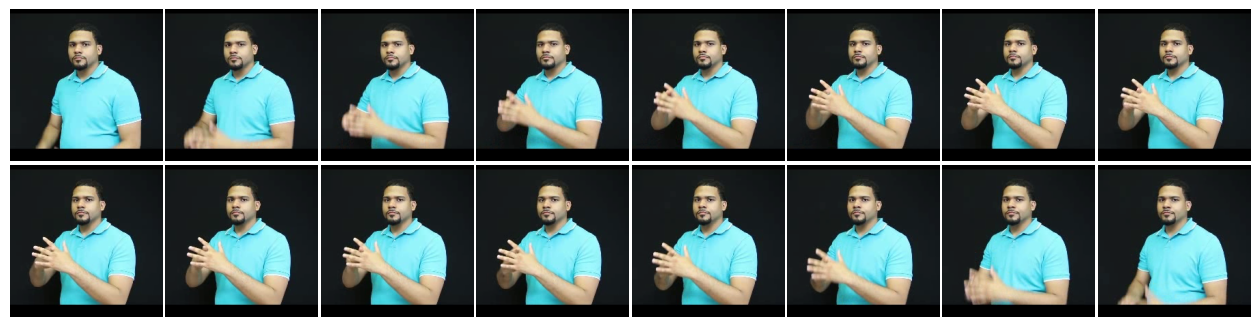

In [22]:
sample_cc = next(iter_cc)
frames_cc, label_num = prep_next2(sample_cc)
print(f"frames: {frames_cc.shape}")
print(f'Class: {class_list[label_num]}')
utils.plt_display_grid(frames_cc, num_frames, size=figsize)

# Looking at what the machine gets wrong

In [23]:
print("--- Underachieving Glosses ---")
ua_instances = []
for gloss in loaded_under_df['Gloss']:
    print(gloss)
    gloss_label = clss_to_idx[gloss]
    print(gloss_label)
    ua_instances.extend(find_instances(test_info, gloss_label))
    
with open('./test_instances_underachievers.json', 'w') as f:
    json.dump(ua_instances,f, indent=4)

--- Underachieving Glosses ---
before
3
thin
14
eat
61
yellow
104
hot
1777
what
30
blue
33
hearing
1131
time
73
wrong
50
corn
56
short
72
need
90
different
112
red
125
bathroom
142
help
12
bowling
34
right
95
check
109
sick
129
blanket
143
call
145
copy
149
first
154
approve
181
new
1833
east
276


In [24]:
ua_info = test_info.copy()
ua_info['labels'] = Path('./')
ua_info['label_suff'] = 'underachievers.json'
ua_set = VideoDataset(
    set_info=ua_info,
    num_frames=num_frames,
    transforms=cc_tranform,   
)
cc_loader = DataLoader(
    ua_set, 
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)
iter_cc = iter(cc_loader)

frames: torch.Size([16, 3, 224, 224])
Class: before


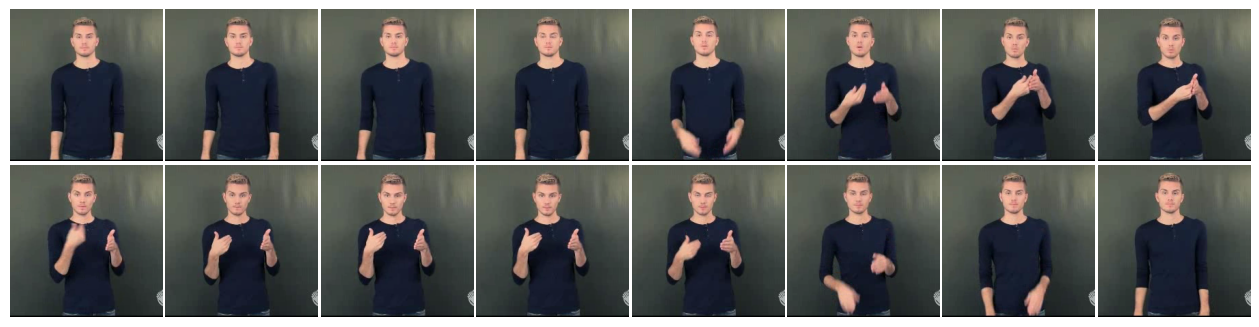

In [29]:
sample_cc = next(iter_cc)
frames_cc, label_num = prep_next2(sample_cc)
print(f"frames: {frames_cc.shape}")
print(f'Class: {class_list[label_num]}')
utils.plt_display_grid(frames_cc, num_frames, size=figsize)

In [26]:

bbcua_set = VideoDataset(
    set_info=ua_info,
    num_frames=num_frames,
    transforms=bbc_transform,   
    item_transforms=vt._crop_frames
)

bbc_loader = DataLoader(
    bbcua_set, 
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)
iter_bbc = iter(bbc_loader)

frames: torch.Size([16, 3, 224, 224])
Class: before


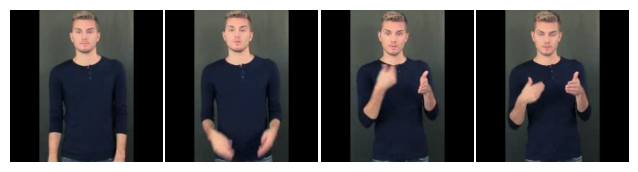

In [30]:
sample_bbc = next(iter_bbc)
frames_bbc, label_num = prep_next2(sample_bbc)
print(f"frames: {frames_bbc.shape}")
print(f'Class: {class_list[label_num]}')
utils.plt_display_grid(frames_bbc, 4, size=figsize, output=f'{class_list[label_num]}.pdf')

In [ ]:
# raise Exception

Exception: 

# Test to see what MVIT predicts for before

In [31]:
device = torch.device('cuda')
model.to(device)
model.eval()

MViTv2S_basic(
  (backbone): ModuleList(
    (0): Conv3d(3, 96, kernel_size=(3, 7, 7), stride=(2, 4, 4), padding=(1, 3, 3))
    (1): PositionalEncoding()
    (2): ModuleList(
      (0): MultiscaleBlock(
        (norm1): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
        (norm2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
        (attn): MultiscaleAttention(
          (qkv): Linear(in_features=96, out_features=288, bias=True)
          (project): Sequential(
            (0): Linear(in_features=96, out_features=96, bias=True)
          )
          (pool_q): Pool(
            (pool): Conv3d(96, 96, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), groups=96, bias=False)
            (norm_act): Sequential(
              (0): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
            )
          )
          (pool_k): Pool(
            (pool): Conv3d(96, 96, kernel_size=(3, 3, 3), stride=(1, 8, 8), padding=(1, 1, 1), groups=96, bias=False)
            (nor

In [32]:
frames = sample_cc['frames']
label_num = sample_cc['label_num']
frames = frames.to(device)

print(type(frames))
print(label_num)

<class 'torch.Tensor'>
tensor([3])


In [33]:
with torch.no_grad():
    predictions = model(frames)
out_labels = np.argsort(predictions.cpu().detach().numpy()[0])
top_pred = torch.argmax(predictions[0]).item()

In [34]:
print(top_pred)

1633


In [35]:
print("--- predicted Glosses ---")
pd_instances = []
gloss = classes[top_pred]
print(gloss)
gloss_label = clss_to_idx[gloss]
print(gloss_label)
pd_instances.extend(find_instances(test_info, gloss_label))
    
with open('./test_instances_predicted.json', 'w') as f:
    json.dump(pd_instances,f, indent=4)

--- predicted Glosses ---
beside
1633


In [36]:
pd_info = test_info.copy()
pd_info['labels'] = Path('./')
pd_info['label_suff'] = 'predicted.json'
pd_set = VideoDataset(
    set_info=pd_info,
    num_frames=num_frames,
    transforms=cc_tranform,   
)
cc_loader = DataLoader(
    pd_set, 
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)
iter_cc = iter(cc_loader)

frames: torch.Size([16, 3, 224, 224])
Class: beside


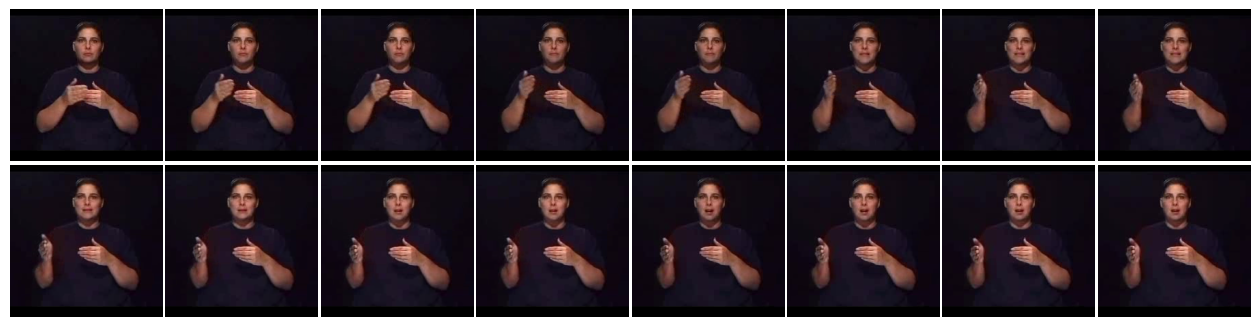

In [37]:
sample_cc = next(iter_cc)
frames_cc, label_num = prep_next2(sample_cc)
print(f"frames: {frames_cc.shape}")
print(f'Class: {class_list[label_num]}')
utils.plt_display_grid(frames_cc, num_frames, size=figsize)

In [38]:
bbcua_set = VideoDataset(
    set_info=pd_info,
    num_frames=num_frames,
    transforms=bbc_transform,   
    item_transforms=vt._crop_frames
)

bbc_loader = DataLoader(
    bbcua_set, 
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)
iter_bbc = iter(bbc_loader)

In [40]:
sample_bbc = next(iter_bbc)
frames_bbc, label_num = prep_next2(sample_bbc)
print(f"frames: {frames_bbc.shape}")
print(f'Class: {class_list[label_num]}')
utils.plt_display_grid(frames_bbc, 4, size=figsize, output=f'{class_list[label_num]}.pdf')

StopIteration: 